<a href="https://colab.research.google.com/github/cras-lab/ML-examples/blob/main/NaiveBayes_SPAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

필요한 모듈을 임포트 한다.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

예제 데이터를 정의한다.

In [4]:
corpus = [
    ("Buy our awesome products at discount!", "spam"),
    ("Hello, how are you today?", "ham"),
    ("URGENT: You have won a prize!", "spam"),
    ("Let's meet for coffee later.", "ham"),
    ("Congratulations, you've won a gift card!", "spam"),
    ("What's your plan for the weekend?", "ham"),
    ("Get a loan with no interest!", "spam"),
    ("Can we reschedule our meeting?", "ham"),
    ("Limited time offer: 50% off!", "spam"),
    ("I'll be there by 3 PM.", "ham"),
    ("You're selected for a free trial.", "spam"),
    ("Are you coming to the party?", "ham"),
    ("Claim your prize now!", "spam"),
    ("Can you please send me the report?", "ham"),
    ("Exclusive deal: Buy one, get one free!", "spam"),
    ("Let's go to the park tomorrow.", "ham"),
    ("Important information regarding your account.", "spam"),
    ("What's your favorite movie?", "ham"),
    ("Last chance to save big!", "spam"),
    ("Let's discuss the project details.", "ham"),
    ("Hurry, offer ends soon!", "spam"),
    ("See you at the conference.", "ham"),
    ("Claim your exclusive membership.", "spam"),
    ("Are you available for a call?", "ham"),
    ("Congratulations, you're the lucky winner!", "spam")
]

데이터와 테이브를 분리한다.<BR>
X = [email for email, label in corpus]
corpus 문장을 email, label로 구분하여, email 부분으로 리스트 생성<BR>
y = [label for email, label in corpus]
corpus 문장을 email, label로 구분하여, label 부분으로 리스트 생성

In [5]:
X = [email for email, label in corpus]
y = [label for email, label in corpus]

텍스트를 벡터로 변환

In [6]:
vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X)

데이터 분할

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

나이브 베이즈 분류기 생성 및 학습

In [8]:
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

MultinomialNB()

테스트 데이터 예측 및 정확도 출력

In [9]:
y_pred = nb_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


단어별 기여도 계산<BR>
contribution_to_spam > 0 : spam 쪽 기여<BR>
contribution_to_spam < 0 : ham 쪽 기여<BR>

In [16]:
feature_names = np.array(vectorizer.get_feature_names_out())

ham_idx = np.where(nb_classifier.classes_ == 'ham')[0][0]
spam_idx = np.where(nb_classifier.classes_ == 'spam')[0][0]

# 각 클래스별 log P(word | class)
#log_prob = nb_classifier.feature_log_prob_

# spam 쪽 기여도
word_contrib = log_prob[spam_idx] - log_prob[ham_idx]

contrib_df = pd.DataFrame({
    'word': feature_names,
    'ham_log_prob': log_prob[ham_idx],
    'spam_log_prob': log_prob[spam_idx],
    'contribution_to_spam': word_contrib
}).sort_values('contribution_to_spam', ascending=False).reset_index(drop=True)

Word-level Contribution 그래프

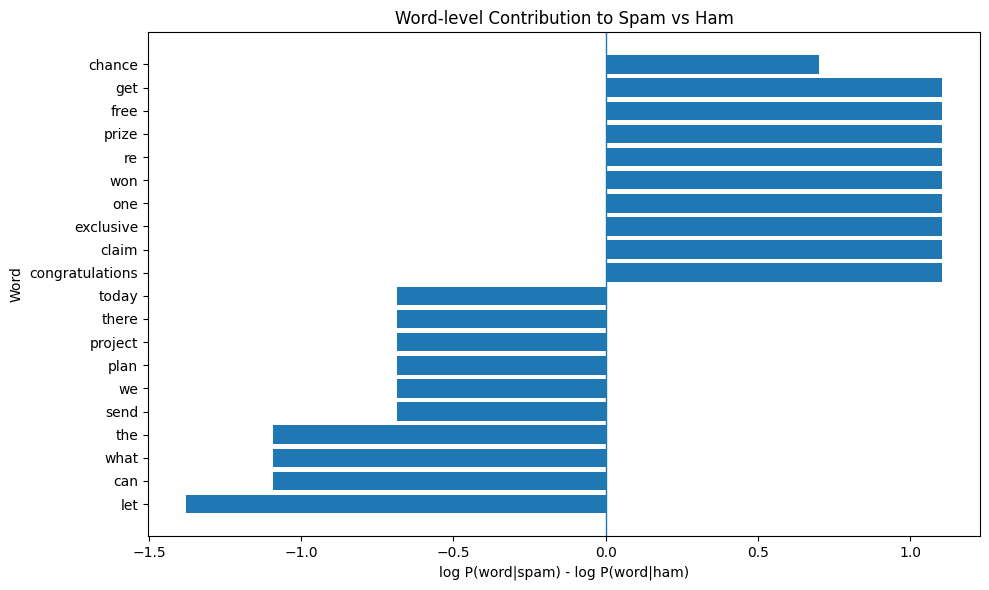

In [17]:
top_spam = contrib_df.head(10)
top_ham = contrib_df.tail(10).sort_values('contribution_to_spam', ascending=True)
plot_df = pd.concat([top_ham, top_spam], axis=0)

plt.figure(figsize=(10, 6))
plt.barh(plot_df['word'], plot_df['contribution_to_spam'])
plt.axvline(0, linewidth=1)
plt.xlabel('log P(word|spam) - log P(word|ham)')
plt.ylabel('Word')
plt.title('Word-level Contribution to Spam vs Ham')
plt.tight_layout()
plt.show()

Heatmap 그래프

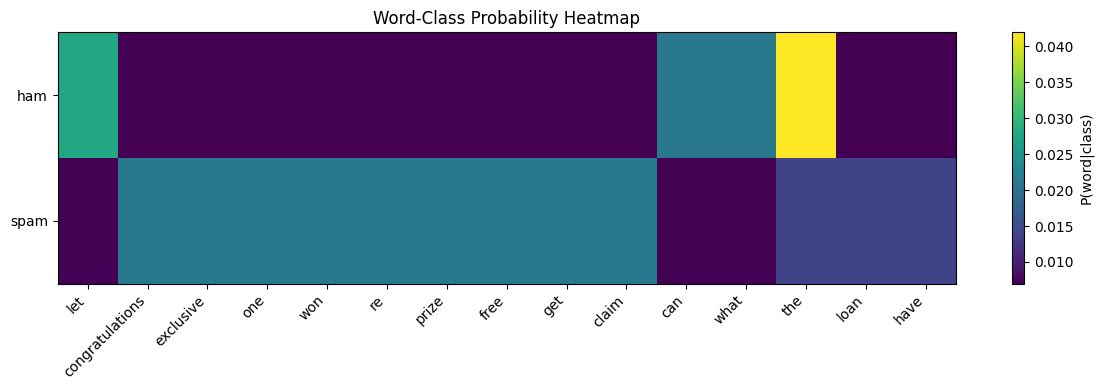

In [14]:
heat_df = contrib_df.copy()
heat_df['abs_contrib'] = heat_df['contribution_to_spam'].abs()
heat_df = heat_df.sort_values('abs_contrib', ascending=False).head(15)

# log 확률을 실제 확률로 변환
heat_mat = np.vstack([
    np.exp(heat_df['ham_log_prob'].values),
    np.exp(heat_df['spam_log_prob'].values)
])

plt.figure(figsize=(12, 4))
plt.imshow(heat_mat, aspect='auto')
plt.xticks(range(len(heat_df)), heat_df['word'], rotation=45, ha='right')
plt.yticks([0, 1], ['ham', 'spam'])
plt.colorbar(label='P(word|class)')
plt.title('Word-Class Probability Heatmap')
plt.tight_layout()
plt.show()

직접 만든 문장 테스트

In [15]:
test_x = [
    "This is last big chance",
    "This is normal email",
    "This Limited offer is best for you"
]

test_vec = vectorizer.transform(test_x)
pred = nb_classifier.predict(test_vec)

print("\n[직접 만든 문장 예측]")
for sentence, label in zip(test_x, pred):
    print(f"{sentence}  -->  {label}")


[직접 만든 문장 예측]
This is last big chance  -->  spam
This is normal email  -->  ham
This Limited offer is best for you  -->  spam
